<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

- Jose Camilo Loaiza Hoyos 
- Sarai Restrepo Rodríguez  

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes 
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

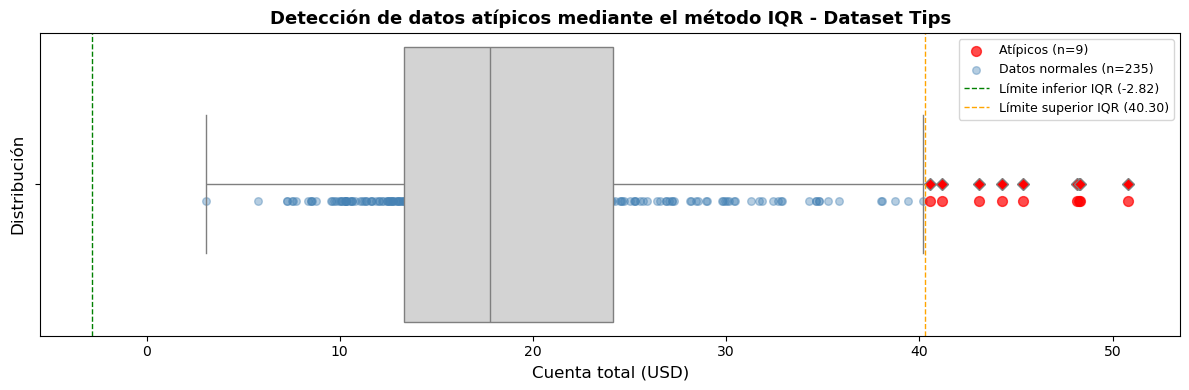

Q1 = 13.35, Q3 = 24.13, IQR = 10.78
Límite inferior = -2.82, Límite superior = 40.30
Cantidad de atípicos detectados: 9
Valores atípicos: [40.55 41.19 43.11 44.3  45.35 48.17 48.27 48.33 50.81]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12, 4))
sns.boxplot(x=total_bill, color="lightgray", flierprops=dict(marker='D', markerfacecolor='red', markersize=6))
plt.scatter(data_a, [0.05] * len(data_a), color="red", s=50, alpha=0.7, zorder=5, label=f"Atípicos (n={len(data_a)})")
plt.scatter(data_b, [0.05] * len(data_b), color="steelblue", s=30, alpha=0.4, label=f"Datos normales (n={len(data_b)})")
plt.axvline(lim_inf, color='green', linestyle='--', linewidth=1, label=f'Límite inferior IQR ({lim_inf:.2f})')
plt.axvline(lim_sup, color='orange', linestyle='--', linewidth=1, label=f'Límite superior IQR ({lim_sup:.2f})')
plt.xlabel("Cuenta total (USD)", fontsize=12)
plt.ylabel("Distribución", fontsize=12)
plt.title("Detección de datos atípicos mediante el método IQR - Dataset Tips", fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Límite inferior = {lim_inf:.2f}, Límite superior = {lim_sup:.2f}")
print(f"Cantidad de atípicos detectados: {len(data_a)}")
print(f"Valores atípicos: {np.sort(data_a)}")

### Análisis – Ejercicio 1 (Método IQR)

El método IQR identifica como atípicos aquellos valores de cuenta total que superan el límite superior (39.35 USD), mientras que no se detectan atípicos por debajo del límite inferior ya que este resulta negativo (-2.25). Los 9 datos atípicos detectados se concentran en la cola derecha de la distribución, evidenciando cuentas inusualmente altas, lo cual es coherente con el sesgo positivo que presenta total_bill, algo esperable en datos de consumo. El boxplot muestra que el 50% central de las cuentas se ubica entre 13.35 y 23.75 USD (Q1 y Q3), con un IQR de 10.40. Los 9 valores atípicos (desde 39.42 hasta 50.81 USD) representan cerca del 4.6% del total de observaciones, sugiriendo eventos poco frecuentes pero no imposibles en cuentas de restaurante.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes 
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

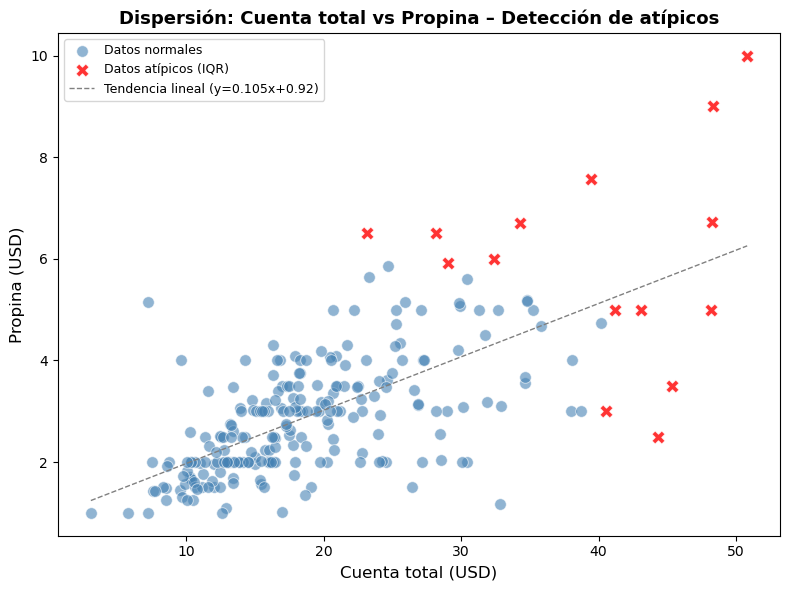

Atípicos detectados: 15 de 244 observaciones


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values

Q1_x, Q3_x = np.percentile(x, [25, 75])
IQR_x = Q3_x - Q1_x
Q1_y, Q3_y = np.percentile(y, [25, 75])
IQR_y = Q3_y - Q1_y

outlier_mask = ((x < Q1_x - 1.5*IQR_x) | (x > Q3_x + 1.5*IQR_x) |
                (y < Q1_y - 1.5*IQR_y) | (y > Q3_y + 1.5*IQR_y))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x[~outlier_mask], y=y[~outlier_mask], s=70, color='steelblue', alpha=0.6, label='Datos normales')
sns.scatterplot(x=x[outlier_mask], y=y[outlier_mask], s=90, color='red', marker='X', alpha=0.8, label='Datos atípicos (IQR)')

# Línea de tendencia
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), color='gray', linestyle='--', linewidth=1, label=f'Tendencia lineal (y={z[0]:.3f}x+{z[1]:.2f})')

plt.xlabel("Cuenta total (USD)", fontsize=12)
plt.ylabel("Propina (USD)", fontsize=12)
plt.title("Dispersión: Cuenta total vs Propina – Detección de atípicos", fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Atípicos detectados: {outlier_mask.sum()} de {len(x)} observaciones")

### Análisis – Ejercicio 2 (Gráfico de dispersión)

Existe una relación lineal positiva entre la cuenta total y la propina: a mayor consumo, mayor propina, lo cual es un comportamiento esperado. Los datos atípicos se identifican aplicando el método IQR de forma independiente a cada variable (total_bill y tip), marcando como atípico cualquier punto que exceda los límites en al menos una de las dos. Se detectan 15 atípicos de 244 observaciones, incluyendo propinas desproporcionadamente altas (superiores a 7 USD) para cuentas moderadas y cuentas extremas por encima de 40 USD. Es importante aclarar que este enfoque no es un método bivariado real, ya que no evalúa la relación conjunta entre variables, para esto se requerirían otras técnicas. Aun así, la visualización en el gráfico de dispersión resulta útil para identificar visualmente puntos que se alejan de la tendencia general.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes 
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

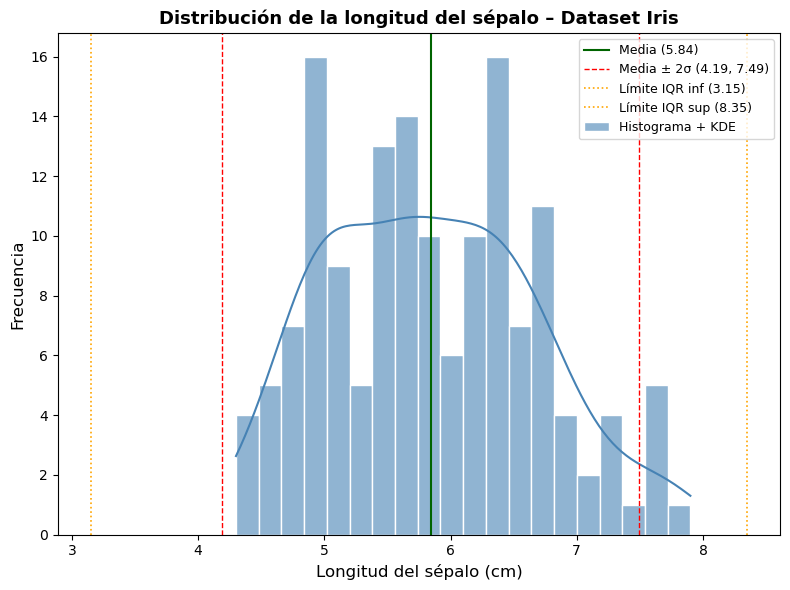

Atípicos IQR: 0 valores -> []


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# Calcular estadísticas y límites IQR
media = np.mean(x)
std = np.std(x)
Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

plt.figure(figsize=(8, 6))
sns.histplot(x=x, bins=20, kde=True, color='steelblue', edgecolor='white', alpha=0.6, label='Histograma + KDE')
plt.axvline(media, color='darkgreen', linestyle='-', linewidth=1.5, label=f'Media ({media:.2f})')
plt.axvline(media - 2*std, color='red', linestyle='--', linewidth=1, label=f'Media ± 2σ ({media-2*std:.2f}, {media+2*std:.2f})')
plt.axvline(media + 2*std, color='red', linestyle='--', linewidth=1)
plt.axvline(lim_inf, color='orange', linestyle=':', linewidth=1.2, label=f'Límite IQR inf ({lim_inf:.2f})')
plt.axvline(lim_sup, color='orange', linestyle=':', linewidth=1.2, label=f'Límite IQR sup ({lim_sup:.2f})')

plt.xlabel("Longitud del sépalo (cm)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Distribución de la longitud del sépalo – Dataset Iris", fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

outliers = x[(x < lim_inf) | (x > lim_sup)]
print(f"Atípicos IQR: {len(outliers)} valores -> {outliers}")

### Análisis – Ejercicio 3 (Histograma y función de densidad)

La distribución de la longitud del sépalo presenta una forma aproximadamente normal con ligera multimodalidad, debido a que el dataset Iris contiene tres especies con características distintas. La curva KDE suaviza el histograma y permite visualizar mejor la forma general, revelando posibles subpoblaciones. Según los límites IQR, prácticamente no se detectan valores atípicos, lo que indica que esta variable no presenta observaciones extremas significativas, y las líneas de media ± 2 desviaciones estándar lo confirman al abarcar la gran mayoría de los datos. La mayor concentración se encuentra entre 5.0 y 6.5 cm, con colas moderadas hacia ambos extremos sin asimetría marcada.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes 
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

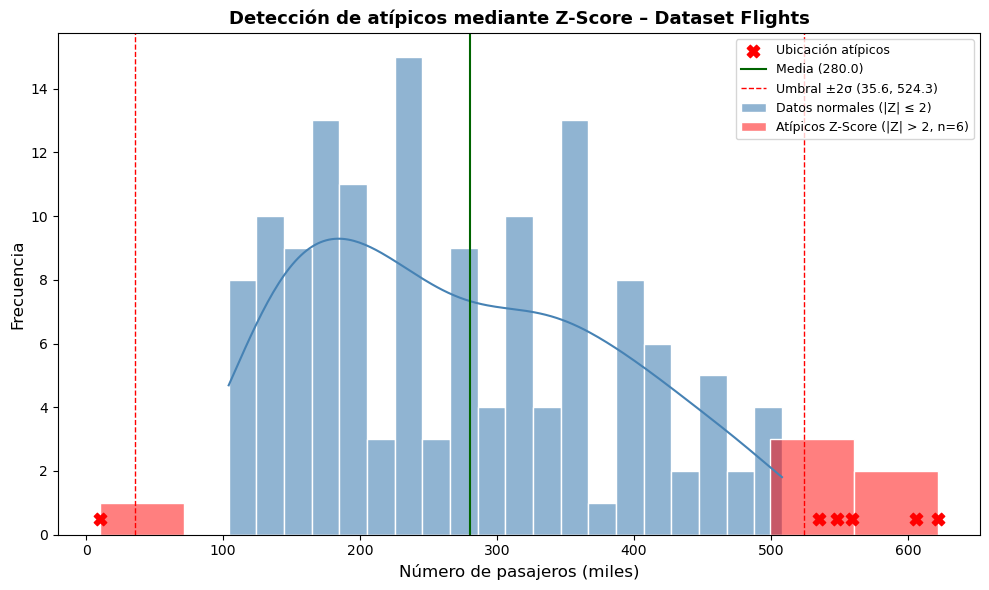

Valores atípicos detectados (|Z| > 2): [548 559 535 622 606  10]
Z-scores correspondientes: [ 2.19  2.28  2.09  2.8   2.67 -2.21]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2  
plt.figure(figsize=(10, 6))
sns.histplot(x=x[~data_b], bins=20, kde=True, color='steelblue', edgecolor='white', alpha=0.6, label='Datos normales (|Z| ≤ 2)')
sns.histplot(x=x[data_b], bins=10, color='red', edgecolor='white', alpha=0.5, label=f'Atípicos Z-Score (|Z| > 2, n={data_b.sum()})')

# Marcar los atípicos en el eje x
plt.scatter(x[data_b], np.zeros_like(x[data_b]) + 0.5, color='red', s=80, marker='X', zorder=5, label='Ubicación atípicos')

media = np.mean(x)
std = np.std(x)
plt.axvline(media, color='darkgreen', linestyle='-', linewidth=1.5, label=f'Media ({media:.1f})')
plt.axvline(media - 2*std, color='red', linestyle='--', linewidth=1, label=f'Umbral ±2σ ({media-2*std:.1f}, {media+2*std:.1f})')
plt.axvline(media + 2*std, color='red', linestyle='--', linewidth=1)

plt.xlabel("Número de pasajeros (miles)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Detección de atípicos mediante Z-Score – Dataset Flights", fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Valores atípicos detectados (|Z| > 2): {x[data_b]}")
print(f"Z-scores correspondientes: {z_scores[data_b].round(2)}")

### Análisis – Ejercicio 4 (Z-Score)

El método Z-Score estandariza los datos y clasifica como atípicos aquellos cuyo valor absoluto de Z supera 2, es decir, a más de 2 desviaciones estándar de la media. Se identifican los valores artificiales agregados (10 y 500) como atípicos: el 10 por la cola izquierda y el 500 por la derecha, ambos muy alejados del rango habitual de pasajeros. Dado que la distribución original muestra un rango creciente a lo largo del tiempo (serie temporal), algunos valores altos naturales del final de la serie también pueden ser señalados como atípicos. Es importante considerar que el Z-Score es sensible a la media y desviación estándar, por lo que la presencia de valores extremos artificiales afecta estos estadísticos y puede alterar la clasificación de otros puntos.